In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv('/content/Train_edited.csv',usecols =['GarageQual','FireplaceQu','SalePrice'])

In [4]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [5]:
df.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


## Using Pandas Impuation

Text(0, 0.5, 'Count')

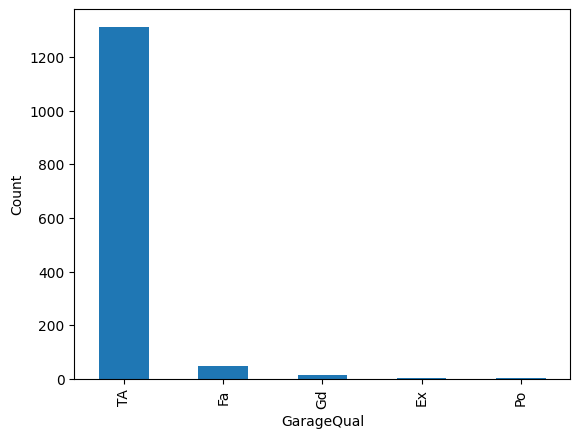

In [6]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Count')


In [7]:
df['GarageQual'].mode()

,GarageQual
0,TA


Text(0.5, 1.0, 'Comaprison between Two Different Values')

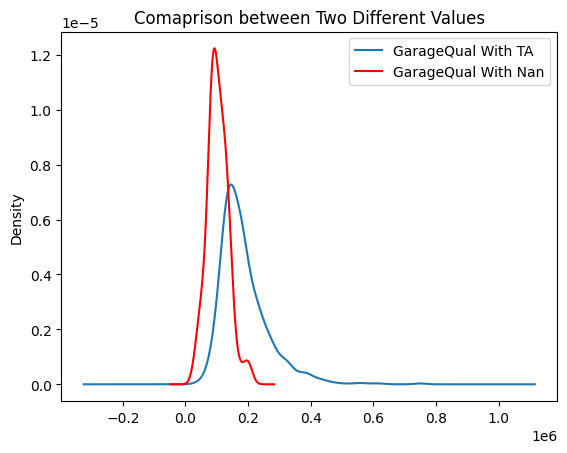

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111)
df[df['GarageQual'] =='TA']['SalePrice'].plot(kind = 'kde',ax = ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind = 'kde',ax = ax,color = 'red')
labels = ['GarageQual With TA','GarageQual With Nan']
plt.legend(labels)
plt.title('Comaprison between Two Different Values')

In [9]:
temp = df[df['GarageQual']== 'TA']['SalePrice']

In [10]:
df['GarageQual'] = df['GarageQual'].fillna('TA')

In [11]:
df['GarageQual'].unique()

array(['TA', 'Fa', 'Gd', 'Ex', 'Po'], dtype=object)

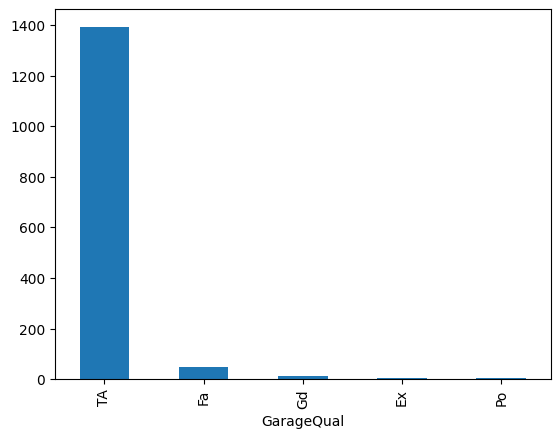

In [12]:
df['GarageQual'].value_counts().plot(kind='bar')
plt.show()

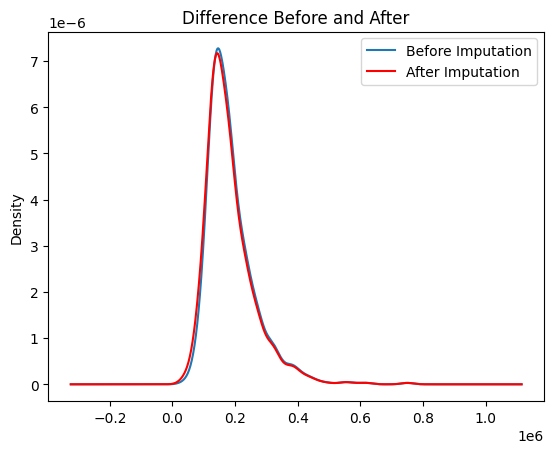

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind = 'kde')

df[df['GarageQual']=='TA']['SalePrice'].plot(kind = 'kde',ax = ax,color = 'red')
labels = ['Before Imputation','After Imputation']
plt.legend(labels)
plt.title('Difference Before and After')

plt.show()

In [14]:
df['FireplaceQu'].mode()

,FireplaceQu
0,Gd


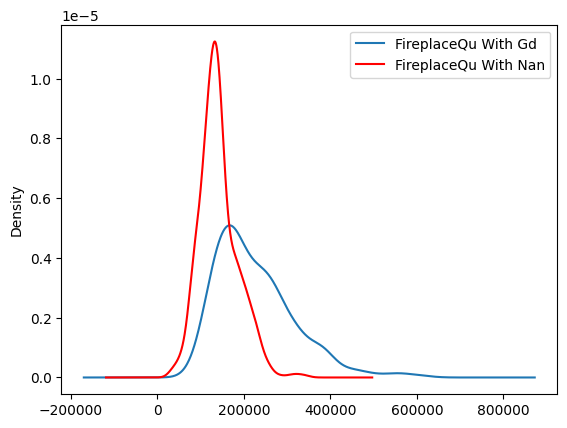

In [17]:
fig = plt.figure()

ax = fig.add_subplot(111)
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind = 'kde',ax = ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind = 'kde',ax = ax,color = 'red')
labels = ['FireplaceQu With Gd','FireplaceQu With Nan']
plt.legend(labels)
plt.show()

In [18]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [19]:
df['FireplaceQu'] = df['FireplaceQu'].fillna('Gd')

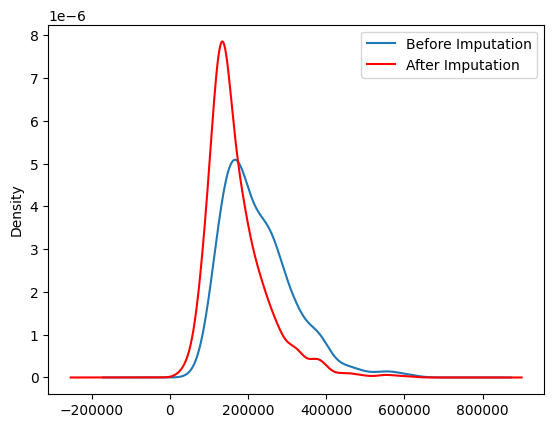

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111)
temp.plot(kind='kde')
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind = 'kde',color='red')
labels= ['Before Imputation','After Imputation']
plt.legend(labels)
plt.show()

## Using Sklearn Imputation

In [22]:
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2,random_state=0)

In [23]:
imputer = SimpleImputer(strategy='most_frequent')

In [26]:
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [27]:
imputer.statistics_


array(['Gd', 'TA'], dtype=object)

# Missing Category Imputation

In [28]:
df = pd.read_csv('/content/Train_edited.csv',usecols =['GarageQual','FireplaceQu','SalePrice'])

In [29]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [30]:
df.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


Text(0, 0.5, 'Count')

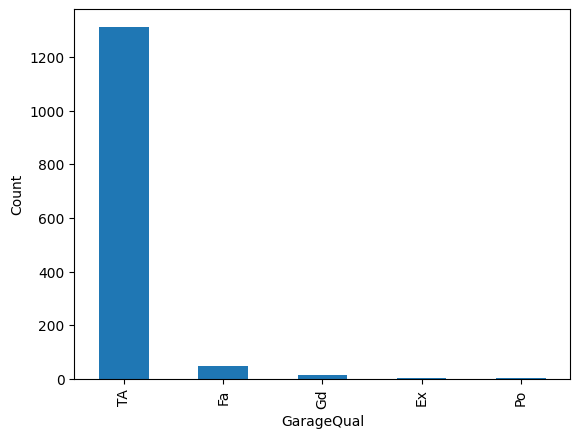

In [32]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Count')


In [35]:
df['GarageQual'] = df['GarageQual'].fillna('Missing')

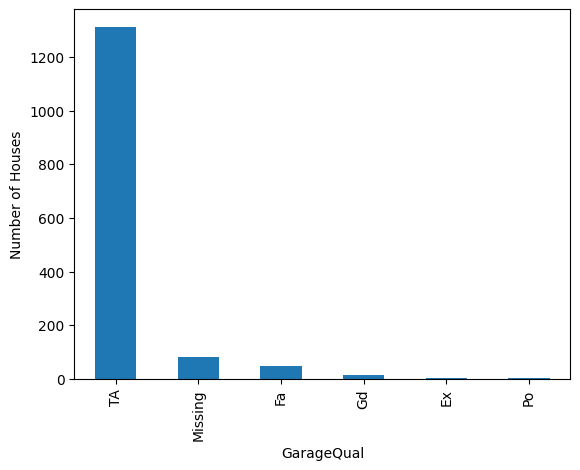

In [40]:
df['GarageQual'].value_counts().plot(kind = 'bar')
plt.xlabel('GarageQual')
plt.ylabel('Number of Houses')
plt.show()

In [41]:
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2,random_state=0)

In [42]:
imputer = SimpleImputer(strategy='constant',fill_value='Missing')

In [44]:
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [45]:
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)